In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

In [2]:
from pypots.data.generating import gene_physionet2012
from pypots.utils.random import set_random_seed

/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



In [3]:
import tsdb

In [4]:
data_ = tsdb.load('italy_air_quality')

2025-03-19 18:37:19 [INFO]: You're using dataset italy_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/italy_air_quality
2025-03-19 18:37:19 [INFO]: Dataset italy_air_quality has already been downloaded. Processing directly...
2025-03-19 18:37:19 [INFO]: Dataset italy_air_quality has already been cached. Loading from cache directly...
2025-03-19 18:37:19 [INFO]: Loaded successfully!


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = data_['X']

# Combine 'Date' and 'Time' into a single datetime column.
# Adjust the format as needed (here the format is: day/month/year hour.minute.second)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# Optional: extract additional time features if they are useful for your ML model
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour

# Drop the original 'Date' and 'Time' columns if they are no longer needed
#df.drop(['Date', 'Time'], axis=1, inplace=True)

# Replace error codes (e.g., -200) with NaN for cleaning
#df.replace(-200, np.nan, inplace=True)

# Identify the columns to normalize.
# If you want to normalize all numeric columns (excluding the datetime column), you can do:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Initialize the scaler (here we use StandardScaler for z-score normalization)
scaler = StandardScaler()

# Fit and transform the numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.sort_values(by = ['Date','Hour'], inplace = True)


# Your dataframe 'df' is now ready for machine learning, with a datetime feature and normalized numeric values.
df.head()



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,Year,Month,Day,Hour
7110,01/01/2005,00.00.00,-2.135042,-0.009066,-0.29267,0.056414,-0.498358,-1.431966,0.164639,-2.033730,-1.056283,0.494465,-0.036534,0.012001,0.186663,2005-01-01 00:00:00,1.778825,-1.544617,-1.688985,-1.660966
7111,01/01/2005,01.00.00,0.461122,0.685263,-0.29267,0.167585,0.103427,0.180184,-0.453419,0.376977,-0.786582,1.404921,-0.103661,0.218978,0.187148,2005-01-01 01:00:00,1.778825,-1.544617,-1.688985,-1.516516
7112,01/01/2005,02.00.00,0.472712,0.375998,-0.29267,0.136167,-0.048480,0.510384,-0.177001,0.558174,-0.833673,0.831509,-0.089773,0.205310,0.187468,2005-01-01 02:00:00,1.778825,-1.544617,-1.688985,-1.372066
7113,01/01/2005,03.00.00,0.475288,0.345678,-0.29267,0.138584,-0.039716,-1.431966,-0.145943,-2.033730,-0.835813,0.702382,-0.112920,0.281462,0.187479,2005-01-01 03:00:00,1.778825,-1.544617,-1.688985,-1.227616
7114,01/01/2005,04.00.00,0.464985,0.015190,-0.29267,0.090249,-0.302631,0.327803,0.108734,0.534540,-0.908590,0.341263,-0.126809,0.308798,0.187368,2005-01-01 04:00:00,1.778825,-1.544617,-1.688985,-1.083166


In [6]:
import pandas as pd
import numpy as np

# Assume df is your preprocessed DataFrame from before,
# and that it contains a 'Datetime' column.
# Define the relevant columns (d features) you wish to use:
relevant_columns = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
                    'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
                    'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# Extract the day and hour from the Datetime column
df['Day'] = df['Datetime'].dt.date
df['Hour'] = df['Datetime'].dt.hour

# Group by day and reindex each day to ensure it has exactly 24 hours.
daily_arrays = []
for day, group in df.groupby('Day'):
    # Set the hour as index and sort by hour
    group = group.set_index('Hour').sort_index()
    # Reindex to ensure every hour from 0 to 23 is present; missing hours will be filled with NaN.
    group = group.reindex(range(24))
    # Extract the relevant columns and convert to a numpy array of shape (24, d)
    daily_array = group[relevant_columns].values
    daily_arrays.append(daily_array)

# Convert list of daily arrays into a single numpy array with shape (N, 24, d)
data_array = np.stack(daily_arrays, axis=0)
print("Shape of the reshaped data:", data_array.shape)


Shape of the reshaped data: (391, 24, 13)


In [8]:
import numpy as np
from pygrinder import mcar
import torch

X = data_array

## Normalize_data
mean, std = np.nanmean(X,axis=0)[None,:], np.nanstd(X, axis=0)[None,:]
std[std==0] = 1
X_normalized = (X - mean) / std
X_normalized = torch.tensor(X_normalized).clip(min=-2,max=2)

X = mcar(torch.clone(X_normalized), p = 0.5)

In [9]:
dataset = {'X' : X}
len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [18]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_UAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpuae = GP_UAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 66, 
            epochs = 500, 
            batch_size = 64,
            alpha = .1,
            beta = .1, 
            sigma = 1e-2,
            K = 1,  
            encoder_sizes = (32, 64,), 
            decoder_sizes = (64,32,),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 30,
            p = 0.3
            )

gpuae.use_gp = False
gpuae.train_gp = False
gpuae.gp.plot_while_training = True
gpuae.model.backbone.device = 'cpu'

from sklearn.impute import KNNImputer
X = np.array(dataset_train['X'].detach().numpy())
imputer = KNNImputer(n_neighbors=2)
imputer.fit(X.reshape(-1,X.shape[-1]))

gpuae.model.backbone.encoder.pre_imputer = imputer

import torch
with torch.autograd.set_detect_anomaly(True):
    gpuae.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-03-19 18:42:04 [INFO]: No given device, using default device: cpu
2025-03-19 18:42:04 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-19 18:42:04 [INFO]: GP_UAE initialized with the given hyperparameters, the number of trainable parameters: 18,353


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=64, out_features=66, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=66, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=66, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=13, bias=True)
  )
)


2025-03-19 18:42:04 [INFO]: Epoch 001 - training loss: 27.8690, validation loss: 27.8504
2025-03-19 18:42:04 [INFO]: Epoch 002 - training loss: 26.7629, validation loss: 29.2878
2025-03-19 18:42:05 [INFO]: Epoch 003 - training loss: 25.9479, validation loss: 30.5598
2025-03-19 18:42:05 [INFO]: Epoch 004 - training loss: 26.0487, validation loss: 31.4836
2025-03-19 18:42:05 [INFO]: Epoch 005 - training loss: 23.4579, validation loss: 32.5746
2025-03-19 18:42:06 [INFO]: Epoch 006 - training loss: 23.9244, validation loss: 33.0546
2025-03-19 18:42:06 [INFO]: Epoch 007 - training loss: 22.2391, validation loss: 32.5472
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/gp_uae/plotting_utils.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
2025-03-19 18:42:07 [INFO]: Epoch 008 - training loss: 21.9507, validation loss: 31.3735
2025-03-19 18:42:08 [INF

training kernel


0it [00:00, ?it/s]

0.1399977058172226 0.29601243138313293


1it [00:04,  4.09s/it]

0.1514521688222885 0.2915320098400116


...

0.14825443923473358 0.28931960463523865


4it [00:17,  4.32s/it]

0.14222443103790283 0.24273714423179626


5it [00:17,  3.59s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


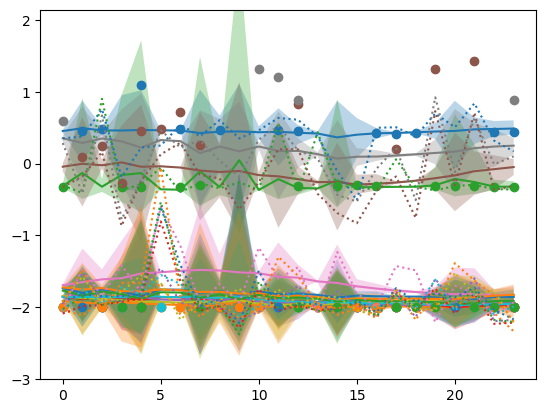

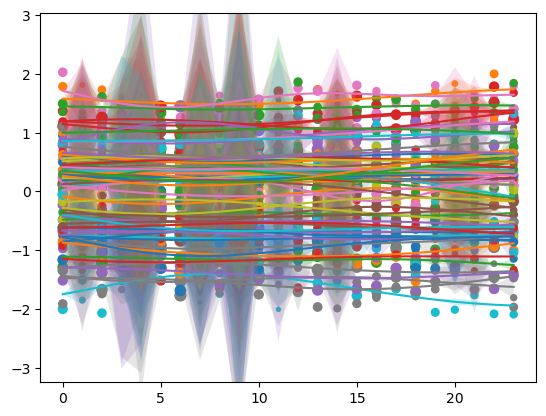

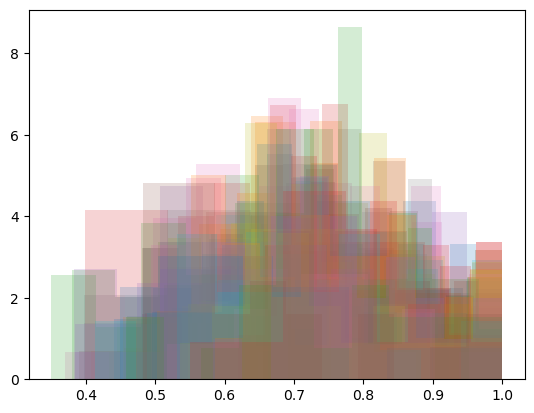

Epoch 2/500: Training Loss = 0.339490, Validation Loss = 0.235303


0it [00:00, ?it/s]

0.13589945435523987 0.26518574357032776


1it [00:04,  4.65s/it]

0.13497698307037354 0.25657814741134644


...

0.11101354658603668 0.21317271888256073


4it [00:17,  4.41s/it]

0.13644203543663025 0.2679484784603119


5it [00:18,  3.76s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


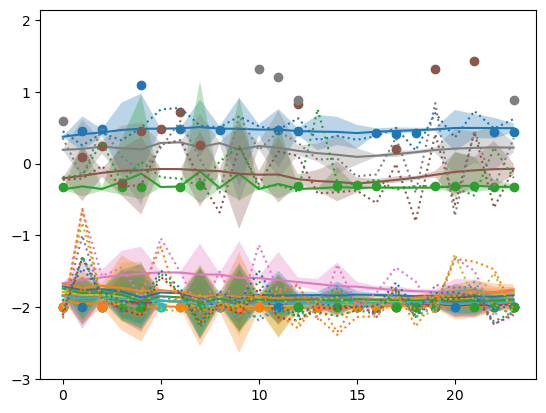

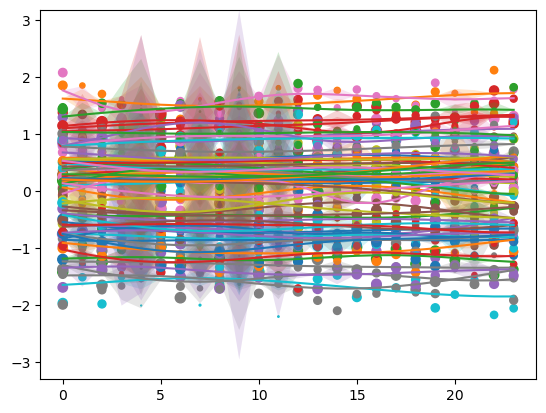

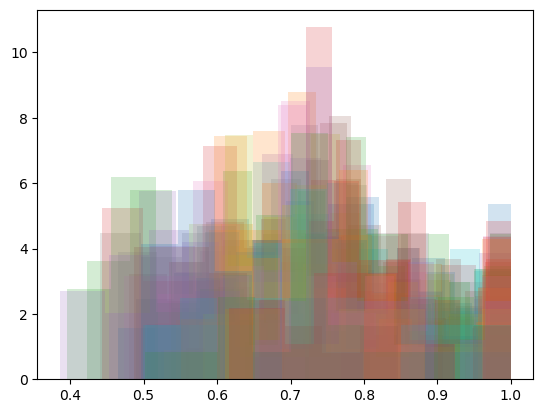

Epoch 3/500: Training Loss = 0.309493, Validation Loss = 0.226935


0it [00:00, ?it/s]

0.12491675466299057 0.21295671164989471


1it [00:04,  4.67s/it]

0.11820995062589645 0.19635866582393646


...

0.10736867785453796 0.20012222230434418


4it [00:18,  4.61s/it]

0.11249212920665741 0.22832055389881134


5it [00:19,  3.88s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


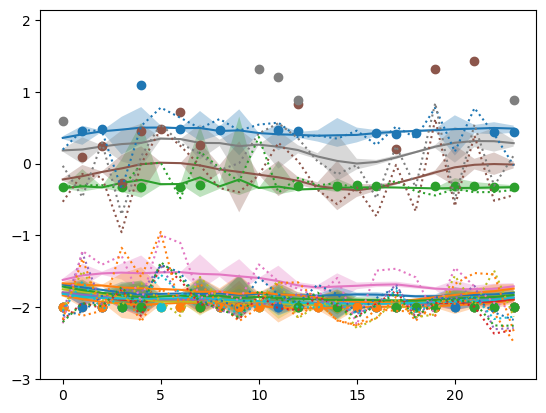

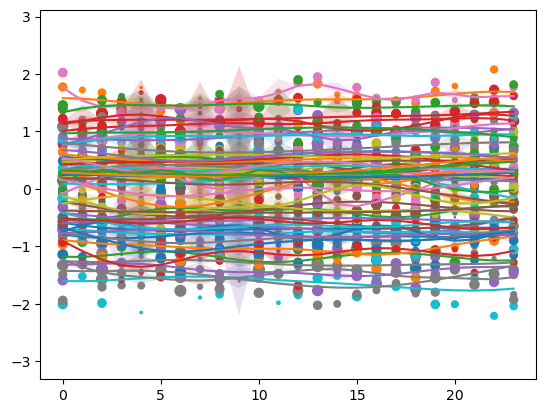

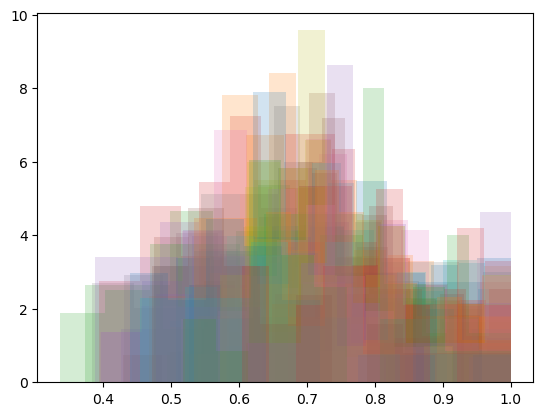

Epoch 4/500: Training Loss = 0.262156, Validation Loss = 0.222452


0it [00:00, ?it/s]

0.10090920329093933 0.19894275069236755


1it [00:04,  4.69s/it]

0.0874522477388382 0.19467349350452423


...

0.0884929671883583 0.18845707178115845


4it [00:18,  4.64s/it]

0.09842516481876373 0.227897047996521


5it [00:19,  3.91s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


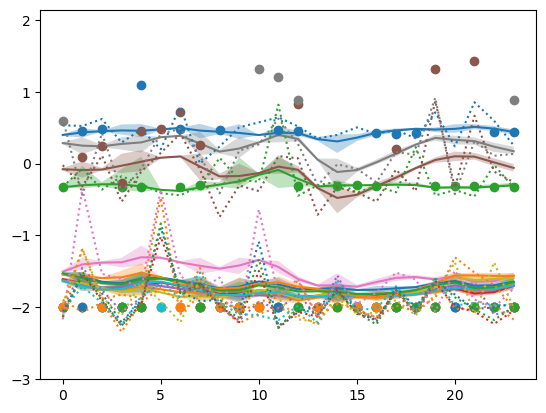

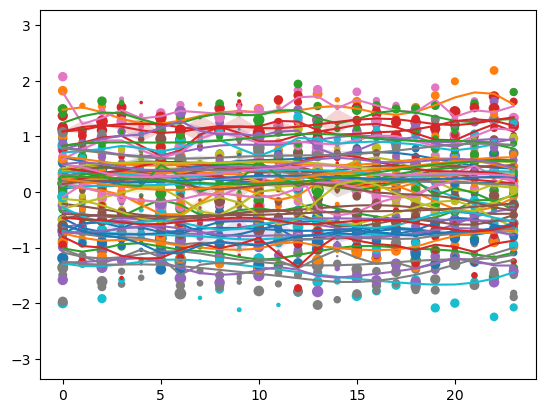

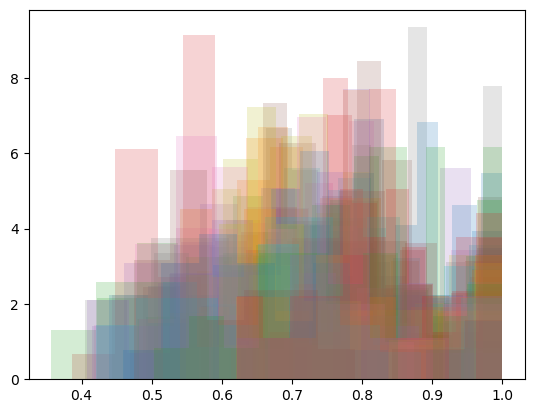

Epoch 5/500: Training Loss = 0.217091, Validation Loss = 0.223648


0it [00:00, ?it/s]

0.07597341388463974 0.18001513183116913


1it [00:04,  4.54s/it]

0.06827125698328018 0.19430433213710785


...

0.0690125823020935 0.20843522250652313


4it [00:18,  4.59s/it]

0.06016436219215393 0.16372480988502502


5it [00:19,  3.82s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


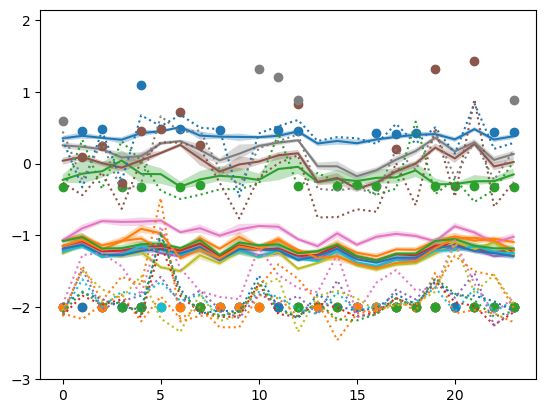

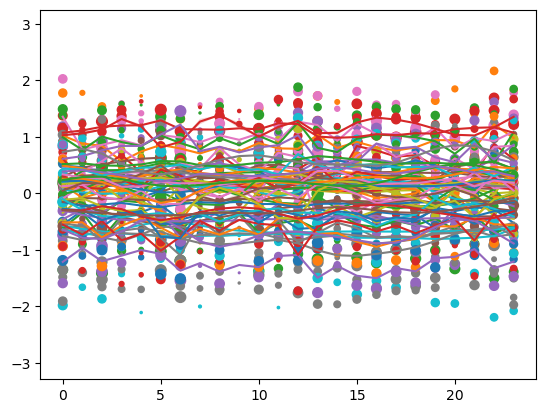

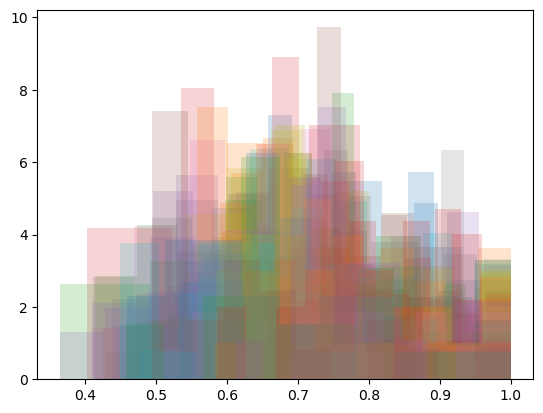

Epoch 6/500: Training Loss = 0.165713, Validation Loss = 0.262515


0it [00:00, ?it/s]

0.06351082026958466 0.2284637689590454


1it [00:04,  4.48s/it]

0.07008977234363556 0.25684311985969543


...

0.05568179860711098 0.23042607307434082


4it [00:17,  4.40s/it]

0.06493325531482697 0.25794821977615356


5it [00:18,  3.68s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


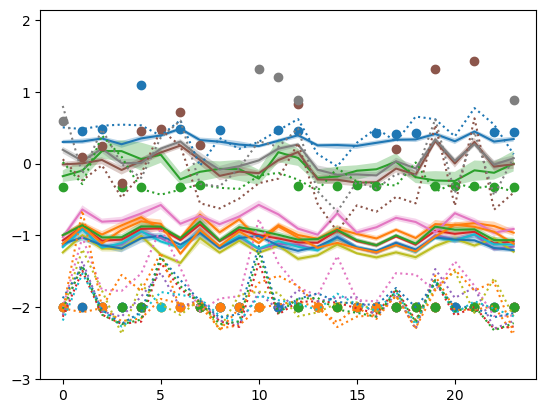

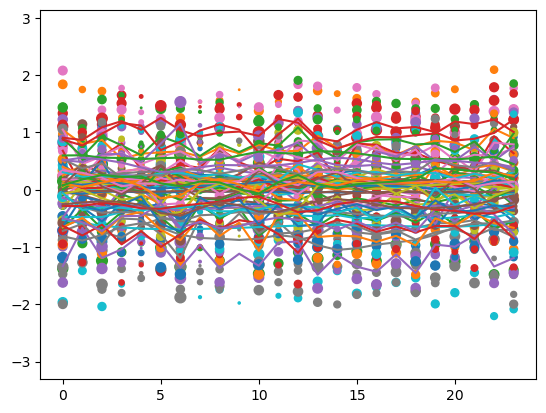

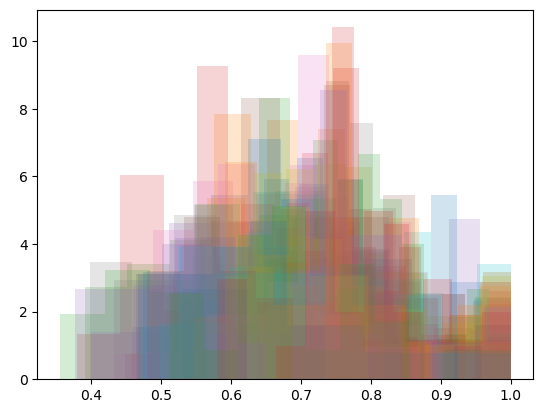

Epoch 7/500: Training Loss = 0.151099, Validation Loss = 0.303883


0it [00:00, ?it/s]

0.05906235799193382 0.245760977268219


1it [00:04,  4.30s/it]

0.05171512812376022 0.2463606745004654


...

0.05037973076105118 0.24936096370220184


4it [00:17,  4.43s/it]

0.04692221060395241 0.2894517481327057


5it [00:18,  3.69s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


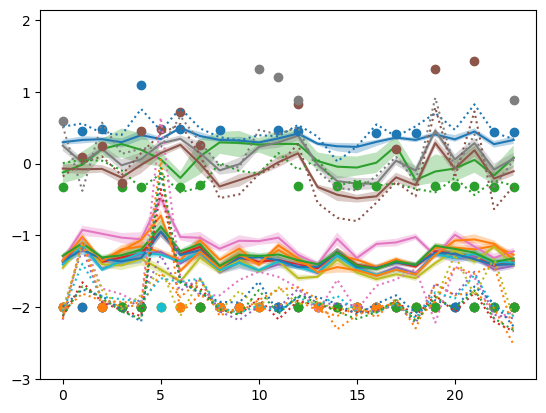

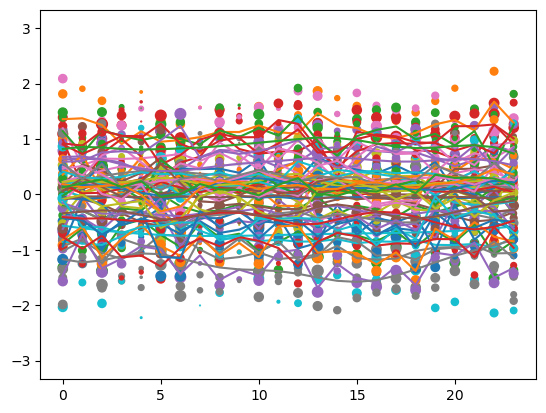

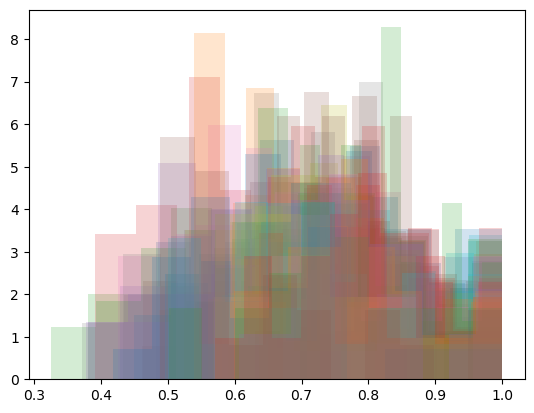

Epoch 8/500: Training Loss = 0.142935, Validation Loss = 0.297559


0it [00:00, ?it/s]

0.038834065198898315 0.21908381581306458


1it [00:04,  4.54s/it]

0.03858551010489464 0.26158472895622253


...

0.03448536992073059 0.23869845271110535


4it [00:17,  4.48s/it]

0.043888188898563385 0.26832807064056396


5it [00:18,  3.75s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


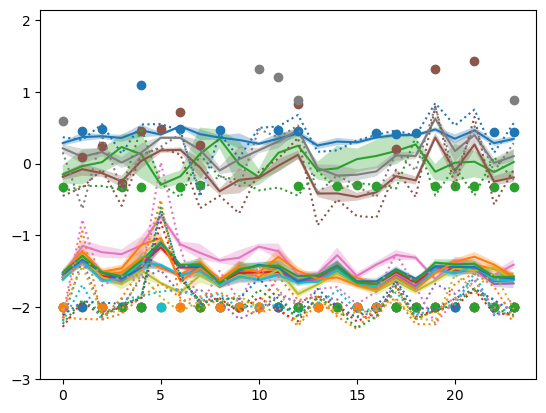

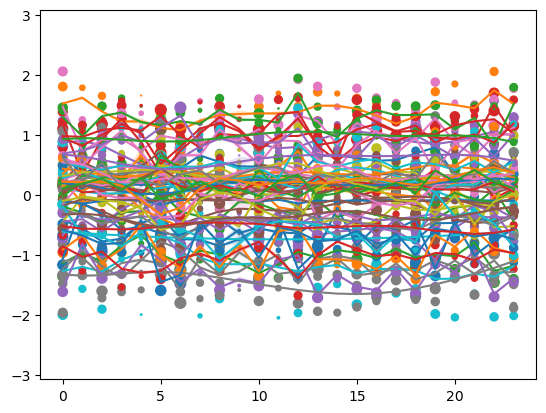

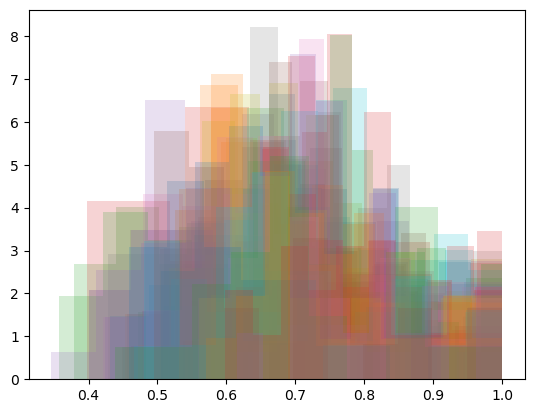

Epoch 9/500: Training Loss = 0.134851, Validation Loss = 0.293857


0it [00:00, ?it/s]

0.03708460554480553 0.25434398651123047


1it [00:04,  4.46s/it]

0.03082648105919361 0.219109445810318


...

0.03224914148449898 0.22987885773181915


4it [00:17,  4.39s/it]

0.03324496001005173 0.22246065735816956


5it [00:18,  3.67s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


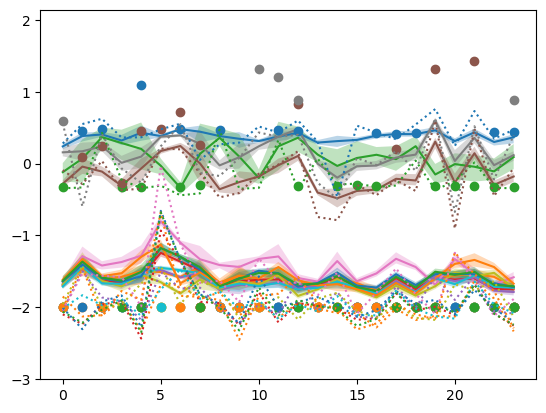

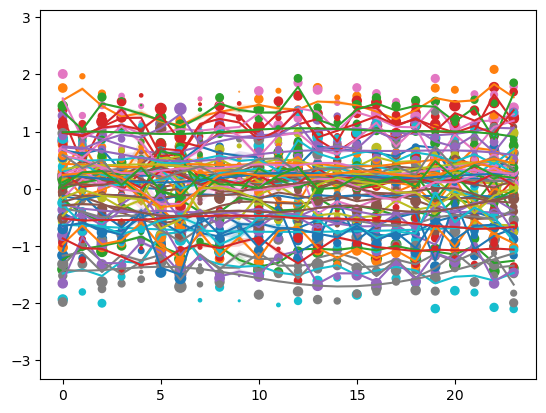

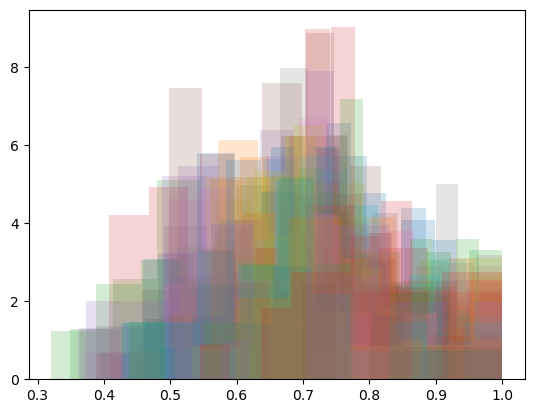

Epoch 10/500: Training Loss = 0.133981, Validation Loss = 0.283003


0it [00:00, ?it/s]

0.02982255443930626 0.22448810935020447


1it [00:04,  4.18s/it]

0.035898562520742416 0.23914121091365814


...

0.031170876696705818 0.235177144408226


4it [00:17,  4.45s/it]

0.027819322422146797 0.20368172228336334


5it [00:18,  3.69s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


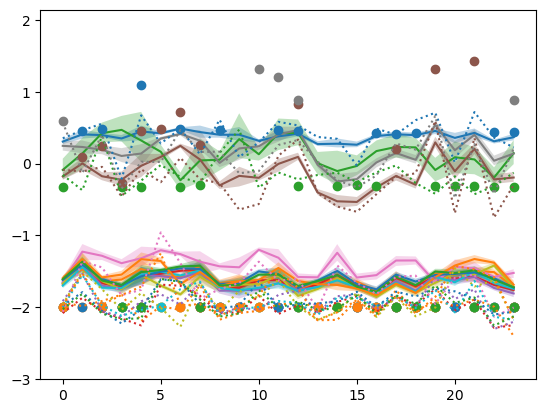

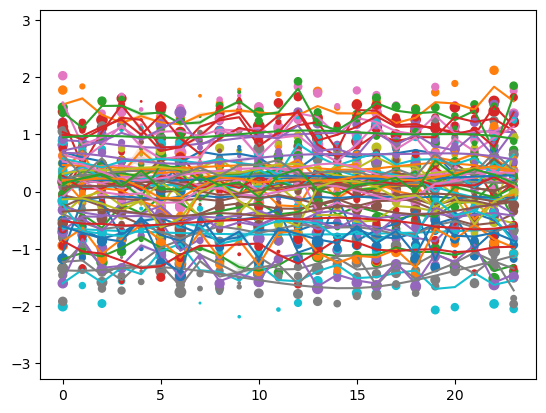

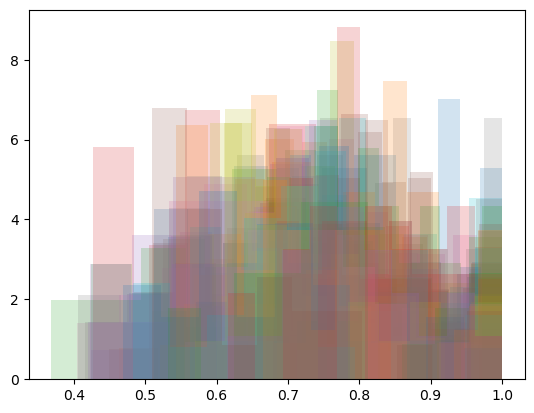

Epoch 11/500: Training Loss = 0.131330, Validation Loss = 0.283675


0it [00:00, ?it/s]

0.033336710184812546 0.2249716967344284


1it [00:04,  4.53s/it]

0.030659638345241547 0.22059528529644012


...

0.032705239951610565 0.22790326178073883


4it [00:18,  4.55s/it]

0.03290247172117233 0.1813460737466812


5it [00:18,  3.78s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


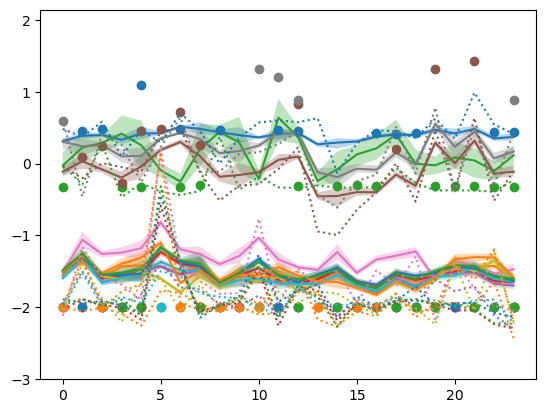

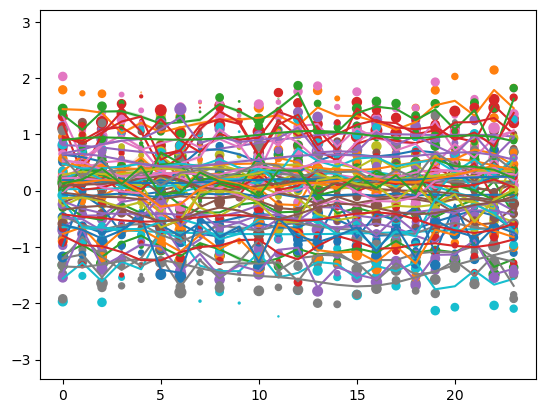

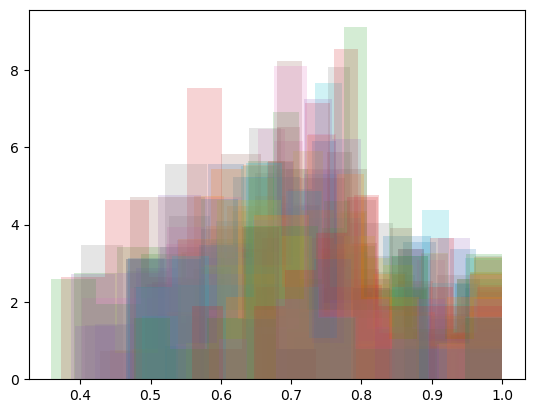

Epoch 12/500: Training Loss = 0.125482, Validation Loss = 0.291142


0it [00:00, ?it/s]

0.03937934339046478 0.25464677810668945


1it [00:04,  4.32s/it]

0.030964961275458336 0.19947412610054016


...

0.03457619622349739 0.23007656633853912


4it [00:17,  4.36s/it]

0.036029037088155746 0.24673378467559814


5it [00:18,  3.66s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


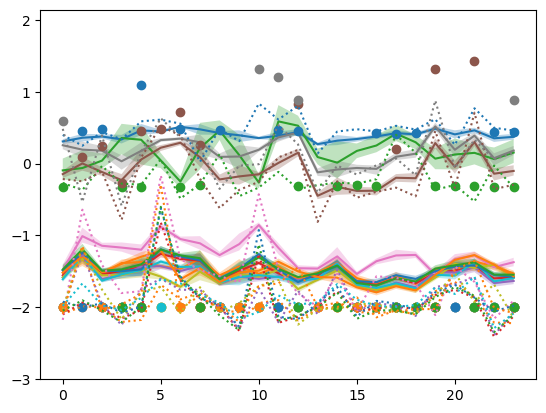

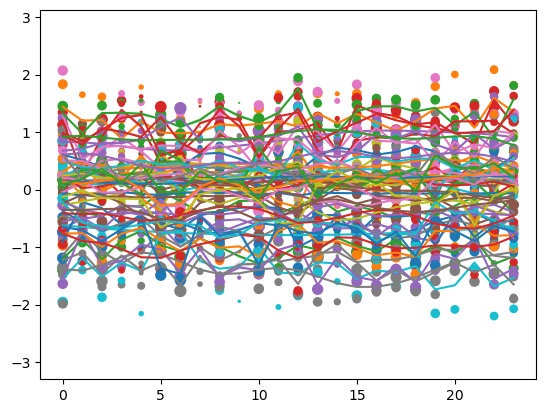

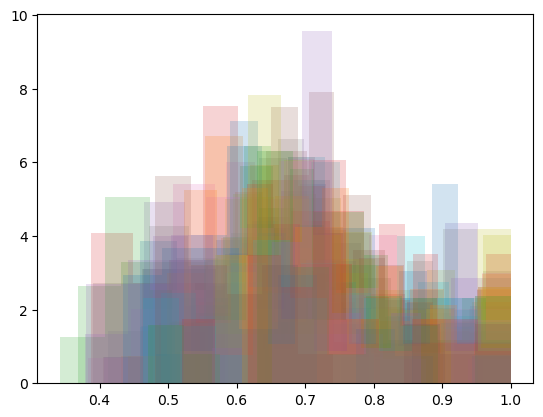

Epoch 13/500: Training Loss = 0.128459, Validation Loss = 0.290605


0it [00:00, ?it/s]

0.032620057463645935 0.20603328943252563


1it [00:04,  4.18s/it]

0.03949778154492378 0.2071792483329773


...

0.033048901706933975 0.21424414217472076


4it [00:17,  4.54s/it]

0.03158634155988693 0.2309744656085968


5it [00:18,  3.77s/it]


torch.Size([64, 24, 13]) torch.Size([64, 24, 13])
torch.Size([54, 24, 13]) torch.Size([54, 24, 13])


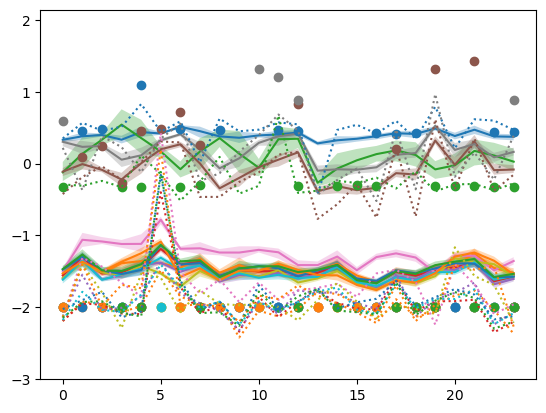

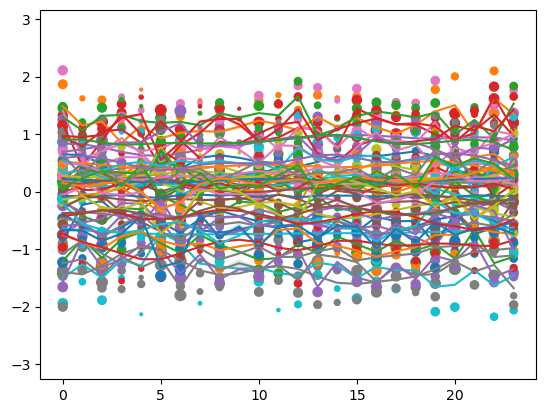

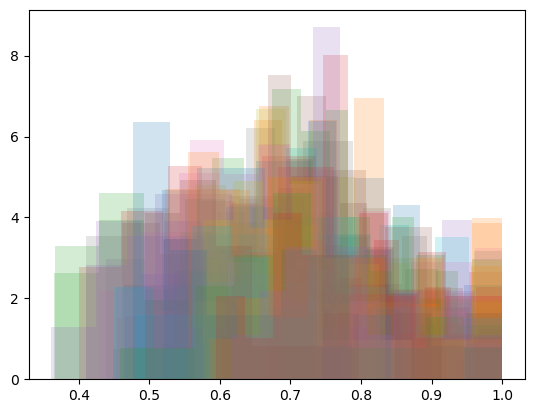

Epoch 14/500: Training Loss = 0.123193, Validation Loss = 0.287566


0it [00:00, ?it/s]

0.038362402468919754 0.24946057796478271


0it [00:04, ?it/s]
2025-03-19 18:54:33 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-03-19 18:54:33 [INFO]: Finished training. The best model is from epoch#3.


KeyboardInterrupt: 

In [28]:
#with torch.autograd.set_detect_anomaly(True):
gpuae.fit(dataset_train, dataset_val, train_kernel_only=True)

In [ ]:
gpvae.fit(dataset_train, dataset_val)

In [22]:
#gpvae.gp.plot_while_training = True
gpuae.fit_kernel(dataset_train, dataset_val, training_iter = 50)

AttributeError: 'GP_UAE' object has no attribute 'fit_kernel'

In [ ]:
torch.save(gpvae.model.backbone.encoder.state_dict().copy(), 'encoder')
torch.save(gpvae.model.backbone.decoder.state_dict().copy(), 'decoder')

In [ ]:
state_dict = torch.load('encoder');
gpvae.model.backbone.encoder.load_state_dict(state_dict);
state_dict = torch.load('decoder');
gpvae.model.backbone.decoder.load_state_dict(state_dict);

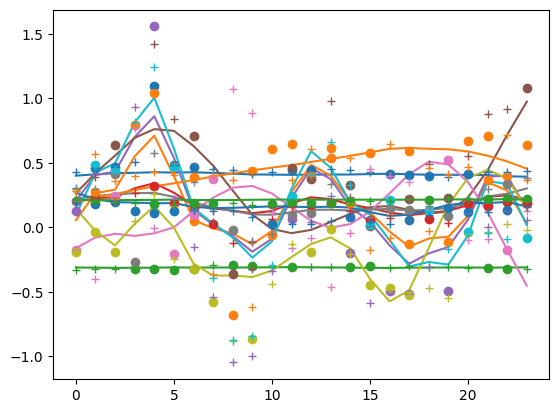

In [108]:
X_val_imputed = gpvae.impute(dataset_val, with_gp = True)
plt.plot(X_val_imputed[0]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X'][0],'o');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X_ori'][0],'+');

In [105]:
mse_obs, mse_hidden = plot_reconstruction_with_GP(X[::5], X_normalized[::5], gpvae, i = 4)

NameError: name 'plot_reconstruction_with_GP' is not defined